# 🧠 Deep Learning (1D-CNN) Comparison
## Feed raw signal directly into a neural network — no manual feature engineering!
---
**Classical ML (Step 2):** We manually extracted 52 features → Random Forest → 100%

**Deep Learning (this step):** We feed the raw echo signal into a 1D-CNN → it learns features automatically

**Why try this?**
- CNN might discover patterns we missed in manual features
- Simpler pipeline (no feature engineering needed)
- Good comparison for your project report

## Cell 1 — Setup & GPU Check

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, gc, csv, os, warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU found: {gpus[0].name}')
    print(f'   TensorFlow version: {tf.__version__}')
else:
    print('⚠️  No GPU detected! Go to Runtime → Change runtime type → GPU')
    print('   Training will be VERY slow without GPU.')

Mounted at /content/drive
✅ GPU found: /physical_device:GPU:0
   TensorFlow version: 2.19.0


## Cell 2 — Load Data

In [ ]:
BASE_DIR = '/content/drive/MyDrive/VER Machine Learning Data'

FILE_PATHS = {
    'human':   os.path.join(BASE_DIR, 'signal_human2.csv'),
    'chair':   os.path.join(BASE_DIR, 'signal_chair2.csv'),
    'nothing': os.path.join(BASE_DIR, 'signal_nothing.csv'),
}

N_METADATA_COLS = 17
N_SIGNAL_SAMPLES = 25000
SAMPLING_RATE = 1_953_125

def count_rows(filepath):
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

def load_csv_efficient(filepath, dtype=np.float32):
    n_rows = count_rows(filepath)
    print(f'  {n_rows} rows', end=' → ')
    signal = np.empty((n_rows, N_SIGNAL_SAMPLES), dtype=dtype)
    chunk_size = 100
    row_idx = 0
    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        batch_rows = []
        for row in reader:
            batch_rows.append(row)
            if len(batch_rows) == chunk_size:
                arr = np.array(batch_rows, dtype=dtype)
                n = arr.shape[0]
                signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
                row_idx += n
                batch_rows = []
        if batch_rows:
            arr = np.array(batch_rows, dtype=dtype)
            n = arr.shape[0]
            signal[row_idx:row_idx+n, :] = arr[:, N_METADATA_COLS:N_METADATA_COLS+N_SIGNAL_SAMPLES]
            row_idx += n
    print(f'Loaded {row_idx} rows.')
    return signal[:row_idx]

signals = {}
for label, path in FILE_PATHS.items():
    print(f'📂 {label.upper()}:', end='')
    signals[label] = load_csv_efficient(path)
    gc.collect()

print('\n✅ All data loaded (signals only — no metadata needed for CNN)!')

📂 HUMAN:  5005 rows → Loaded 5005 rows.
📂 CHAIR:  5000 rows → Loaded 5000 rows.
📂 NOTHING:  5002 rows → Loaded 5002 rows.

✅ All data loaded (signals only — no metadata needed for CNN)!


## Cell 3 — Downsample & Prepare Data for CNN
25,000 samples per signal is too large for CNN. We downsample to **2,500** (10x reduction).
This keeps the important echo patterns while being memory-efficient.

In [ ]:
DOWNSAMPLE_FACTOR = 10
DS_LENGTH = N_SIGNAL_SAMPLES // DOWNSAMPLE_FACTOR  # 2500

label_map = {'human': 0, 'chair': 1, 'nothing': 2}
label_names = ['Human', 'Chair', 'Nothing']

def downsample(signal_array, factor):
    """Downsample by averaging every 'factor' consecutive samples."""
    n_samples, n_points = signal_array.shape
    new_length = n_points // factor
    reshaped = signal_array[:, :new_length * factor].reshape(n_samples, new_length, factor)
    return np.mean(reshaped, axis=2)

# Downsample each class
print(f'Downsampling {N_SIGNAL_SAMPLES} → {DS_LENGTH} (factor {DOWNSAMPLE_FACTOR}x)\n')

ds_signals = {}
for label in ['human', 'chair', 'nothing']:
    ds_signals[label] = downsample(signals[label], DOWNSAMPLE_FACTOR)
    print(f'  {label.upper()}: {signals[label].shape} → {ds_signals[label].shape}')

# Free original signals
del signals
gc.collect()

# Normalize each signal to zero mean, unit variance (per-sample normalization)
print(f'\nNormalizing signals (per-sample zero mean, unit variance)...')
for label in ds_signals:
    mean = ds_signals[label].mean(axis=1, keepdims=True)
    std = ds_signals[label].std(axis=1, keepdims=True) + 1e-8
    ds_signals[label] = (ds_signals[label] - mean) / std

print('✅ Done!')
print(f'   Signal shape per sample: {DS_LENGTH} time steps')
print(f'   RAM usage: ~{sum(s.nbytes for s in ds_signals.values()) / 1e6:.1f} MB')

Downsampling 25000 → 2500 (factor 10x)

  HUMAN: (5005, 25000) → (5005, 2500)
  CHAIR: (5000, 25000) → (5000, 2500)
  NOTHING: (5002, 25000) → (5002, 2500)

Normalizing signals (per-sample zero mean, unit variance)...
✅ Done!
   Signal shape per sample: 2500 time steps
   RAM usage: ~150.1 MB


## Cell 4 — Temporal Train/Test Split
Same as validation: first 80% train, last 20% test (no data leakage).

In [ ]:
SPLIT_RATIO = 0.8

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

for label in ['human', 'chair', 'nothing']:
    sig = ds_signals[label]
    n = len(sig)
    split_idx = int(n * SPLIT_RATIO)

    X_train_list.append(sig[:split_idx])
    X_test_list.append(sig[split_idx:])
    y_train_list.append(np.full(split_idx, label_map[label]))
    y_test_list.append(np.full(n - split_idx, label_map[label]))

    print(f'  {label.upper():8s}: Train={split_idx}, Test={n-split_idx}')

X_train = np.vstack(X_train_list)
X_test = np.vstack(X_test_list)
y_train = np.concatenate(y_train_list)
y_test = np.concatenate(y_test_list)

# Free downsampled signals
del ds_signals, X_train_list, X_test_list
gc.collect()

# Shuffle training data (important for neural networks)
shuffle_idx = np.random.RandomState(42).permutation(len(y_train))
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]

# Reshape for CNN: (samples, time_steps, channels=1)
X_train_cnn = X_train[..., np.newaxis]  # shape: (N, 2500, 1)
X_test_cnn = X_test[..., np.newaxis]

# Further split train into train + validation (for early stopping)
val_split = int(len(X_train_cnn) * 0.85)
X_val_cnn = X_train_cnn[val_split:]
y_val = y_train[val_split:]
X_train_cnn_final = X_train_cnn[:val_split]
y_train_final = y_train[:val_split]

print(f'\n✅ Data prepared for CNN:')
print(f'   Train: {X_train_cnn_final.shape}')
print(f'   Val:   {X_val_cnn.shape}')
print(f'   Test:  {X_test_cnn.shape}')

  HUMAN   : Train=4004, Test=1001
  CHAIR   : Train=4000, Test=1000
  NOTHING : Train=4001, Test=1001

✅ Data prepared for CNN:
   Train: (10204, 2500, 1)
   Val:   (1801, 2500, 1)
   Test:  (3002, 2500, 1)


## Cell 5 — Build 1D-CNN Model
Architecture: Conv1D blocks with increasing filters → Global Pooling → Dense layers

In [ ]:
def build_cnn_model(input_length=2500, n_classes=3):
    """
    1D-CNN for signal classification.
    Architecture:
      Conv1D(32, 7) → BN → ReLU → MaxPool
      Conv1D(64, 5) → BN → ReLU → MaxPool
      Conv1D(128, 3) → BN → ReLU → MaxPool
      Conv1D(256, 3) → BN → ReLU → GlobalAvgPool
      Dense(128) → Dropout → Dense(64) → Dropout → Dense(3, softmax)
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=(input_length, 1)),

        # Block 1
        layers.Conv1D(32, kernel_size=7, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=4),

        # Block 2
        layers.Conv1D(64, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=4),

        # Block 3
        layers.Conv1D(128, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=4),

        # Block 4
        layers.Conv1D(256, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.GlobalAveragePooling1D(),

        # Classifier
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax'),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_cnn = build_cnn_model(input_length=DS_LENGTH)
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 2500, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 2500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 625, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 156, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 156, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 156, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 156, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 39, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 39, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 39, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 39, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,091 (691.76 KB)

 Trainable params: 176,131 (688.01 KB)

 Non-trainable params: 960 (3.75 KB)

## Cell 6 — Train the CNN

In [ ]:
# Callbacks
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train
print('🚀 Training 1D-CNN...')
print(f'   Using temporal split (first 80% train, last 20% test)\n')

t0 = time.time()

history = model_cnn.fit(
    X_train_cnn_final, y_train_final,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[cb_early_stop, cb_reduce_lr],
    verbose=1
)

train_time_cnn = time.time() - t0
print(f'\n✅ Training complete in {train_time_cnn:.1f}s')
print(f'   Best val accuracy: {max(history.history["val_accuracy"])*100:.2f}%')

🚀 Training 1D-CNN...
   Using temporal split (first 80% train, last 20% test)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.9597 - loss: 0.1190 - val_accuracy: 0.5580 - val_loss: 2.8765 - learning_rate: 0.0010
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9926 - loss: 0.0292 - val_accuracy: 0.6258 - val_loss: 1.8932 - learning_rate: 0.0010
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9944 - loss: 0.0223 - val_accuracy: 0.8906 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9953 - loss: 0.0169 - val_accuracy: 0.9972 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9948 - loss: 0.0153 - val_accuracy: 0.9978 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9977 - loss: 0.0084 - val_accuracy: 0.9994 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 

## Cell 7 — Training History Plot

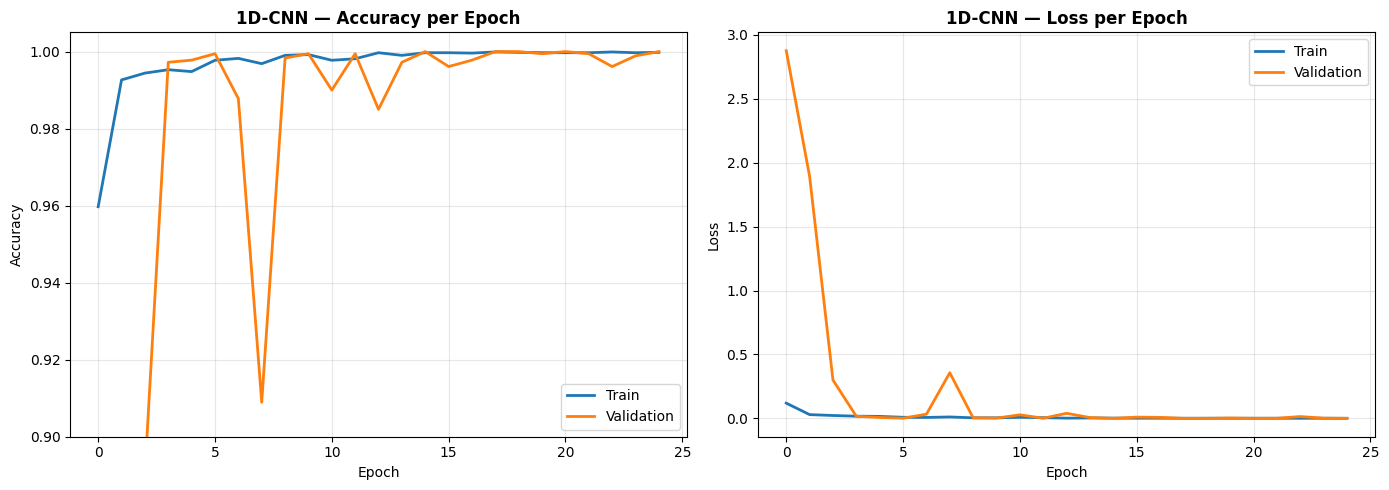

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
ax.plot(history.history['accuracy'], label='Train', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax.set_title('1D-CNN — Accuracy per Epoch', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.9, 1.005)

# Loss
ax = axes[1]
ax.plot(history.history['loss'], label='Train', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax.set_title('1D-CNN — Loss per Epoch', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/step3_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Evaluate CNN on Test Set


1D-CNN Test Results (Temporal Split):
  Accuracy: 99.33%
  Predict time (3002 samples): 2.665s
  Predict time per sample: 0.89ms

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      1001
       Chair       1.00      1.00      1.00      1000
     Nothing       0.98      1.00      0.99      1001

    accuracy                           0.99      3002
   macro avg       0.99      0.99      0.99      3002
weighted avg       0.99      0.99      0.99      3002



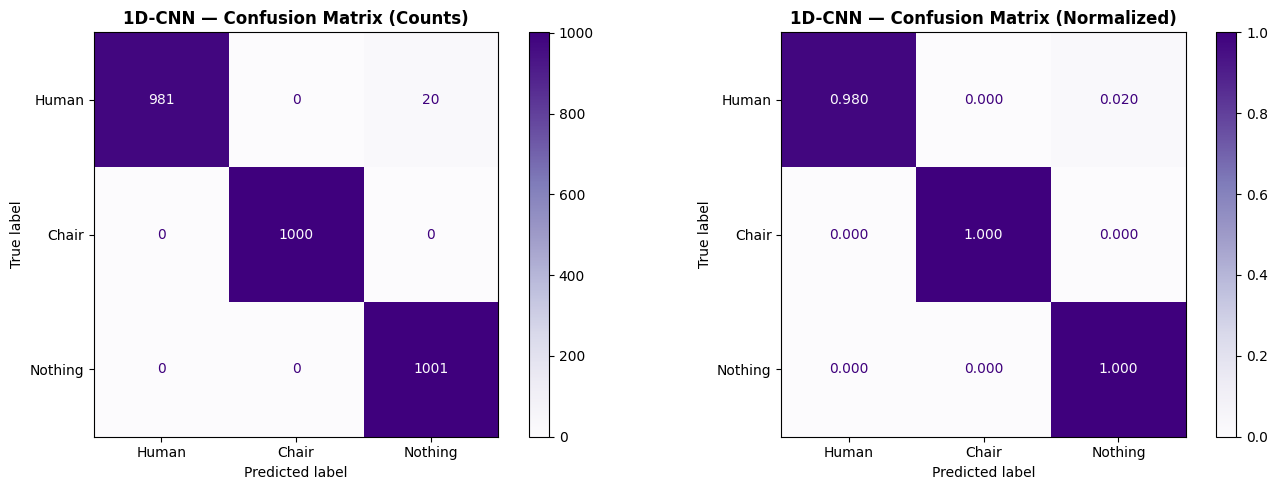

In [ ]:
# Predict on test set
t0 = time.time()
y_pred_proba = model_cnn.predict(X_test_cnn, verbose=0)
predict_time_cnn = time.time() - t0

y_pred_cnn = np.argmax(y_pred_proba, axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

print(f'\n1D-CNN Test Results (Temporal Split):')
print(f'  Accuracy: {acc_cnn*100:.2f}%')
print(f'  Predict time ({len(y_test)} samples): {predict_time_cnn:.3f}s')
print(f'  Predict time per sample: {predict_time_cnn/len(y_test)*1000:.2f}ms')

# Classification report
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_cnn, target_names=label_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(ax=axes[0], cmap='Purples', values_format='d')
axes[0].set_title(f'1D-CNN — Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred_cnn, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=label_names)
disp2.plot(ax=axes[1], cmap='Purples', values_format='.3f')
axes[1].set_title(f'1D-CNN — Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/step3_cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Prediction Confidence Analysis

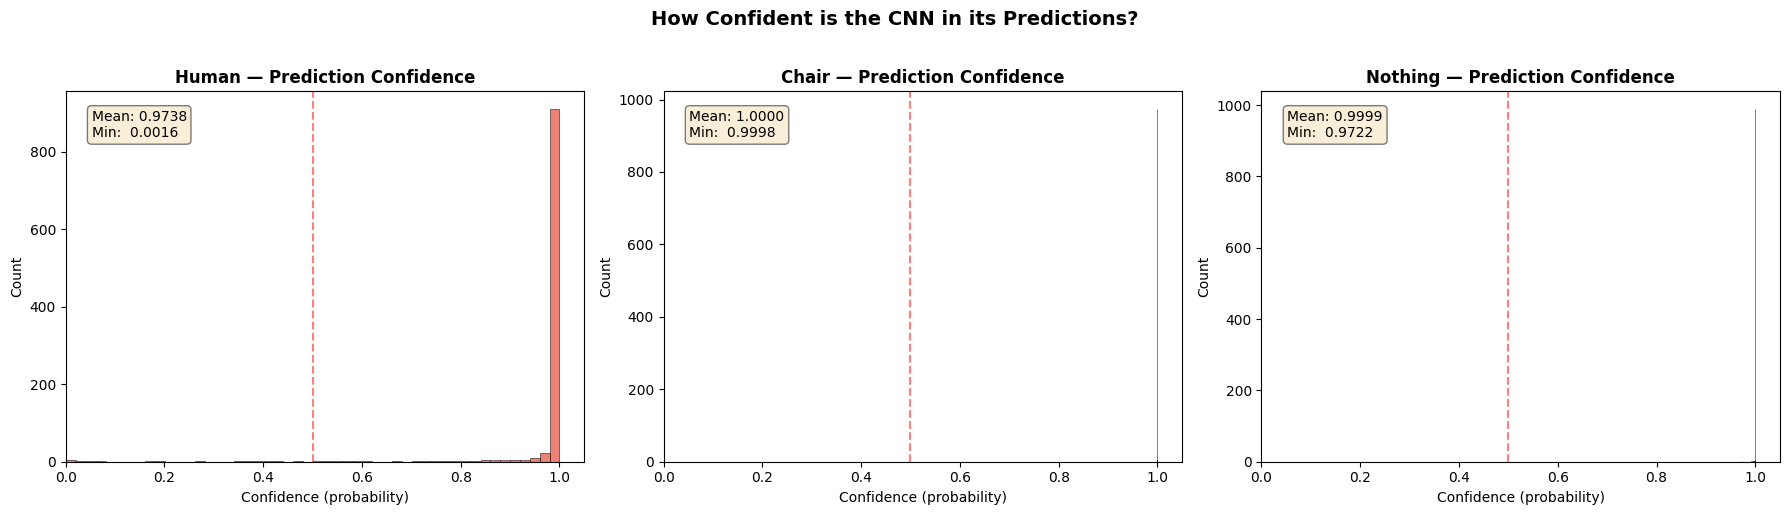


Confidence Statistics:
  Mean confidence: 99.53%
  Min confidence:  51.52%
  Samples with <90% confidence: 43
  Samples with <95% confidence: 56


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for class_idx, class_name in enumerate(label_names):
    ax = axes[class_idx]
    mask = y_test == class_idx

    # Confidence for the correct class
    correct_confidence = y_pred_proba[mask, class_idx]

    ax.hist(correct_confidence, bins=50, color=['#e74c3c', '#3498db', '#2ecc71'][class_idx],
            alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{class_name} — Prediction Confidence', fontweight='bold')
    ax.set_xlabel('Confidence (probability)')
    ax.set_ylabel('Count')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_xlim(0, 1.05)

    # Stats
    ax.text(0.05, 0.95, f'Mean: {correct_confidence.mean():.4f}\nMin:  {correct_confidence.min():.4f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

plt.suptitle('How Confident is the CNN in its Predictions?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/step3_cnn_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

# Find least confident predictions
max_proba = np.max(y_pred_proba, axis=1)
print(f'\nConfidence Statistics:')
print(f'  Mean confidence: {max_proba.mean()*100:.2f}%')
print(f'  Min confidence:  {max_proba.min()*100:.2f}%')
print(f'  Samples with <90% confidence: {(max_proba < 0.9).sum()}')
print(f'  Samples with <95% confidence: {(max_proba < 0.95).sum()}')

## Cell 10 — What the CNN Learned (Grad-CAM Visualization)
Shows WHICH parts of the signal the CNN focuses on for each class.

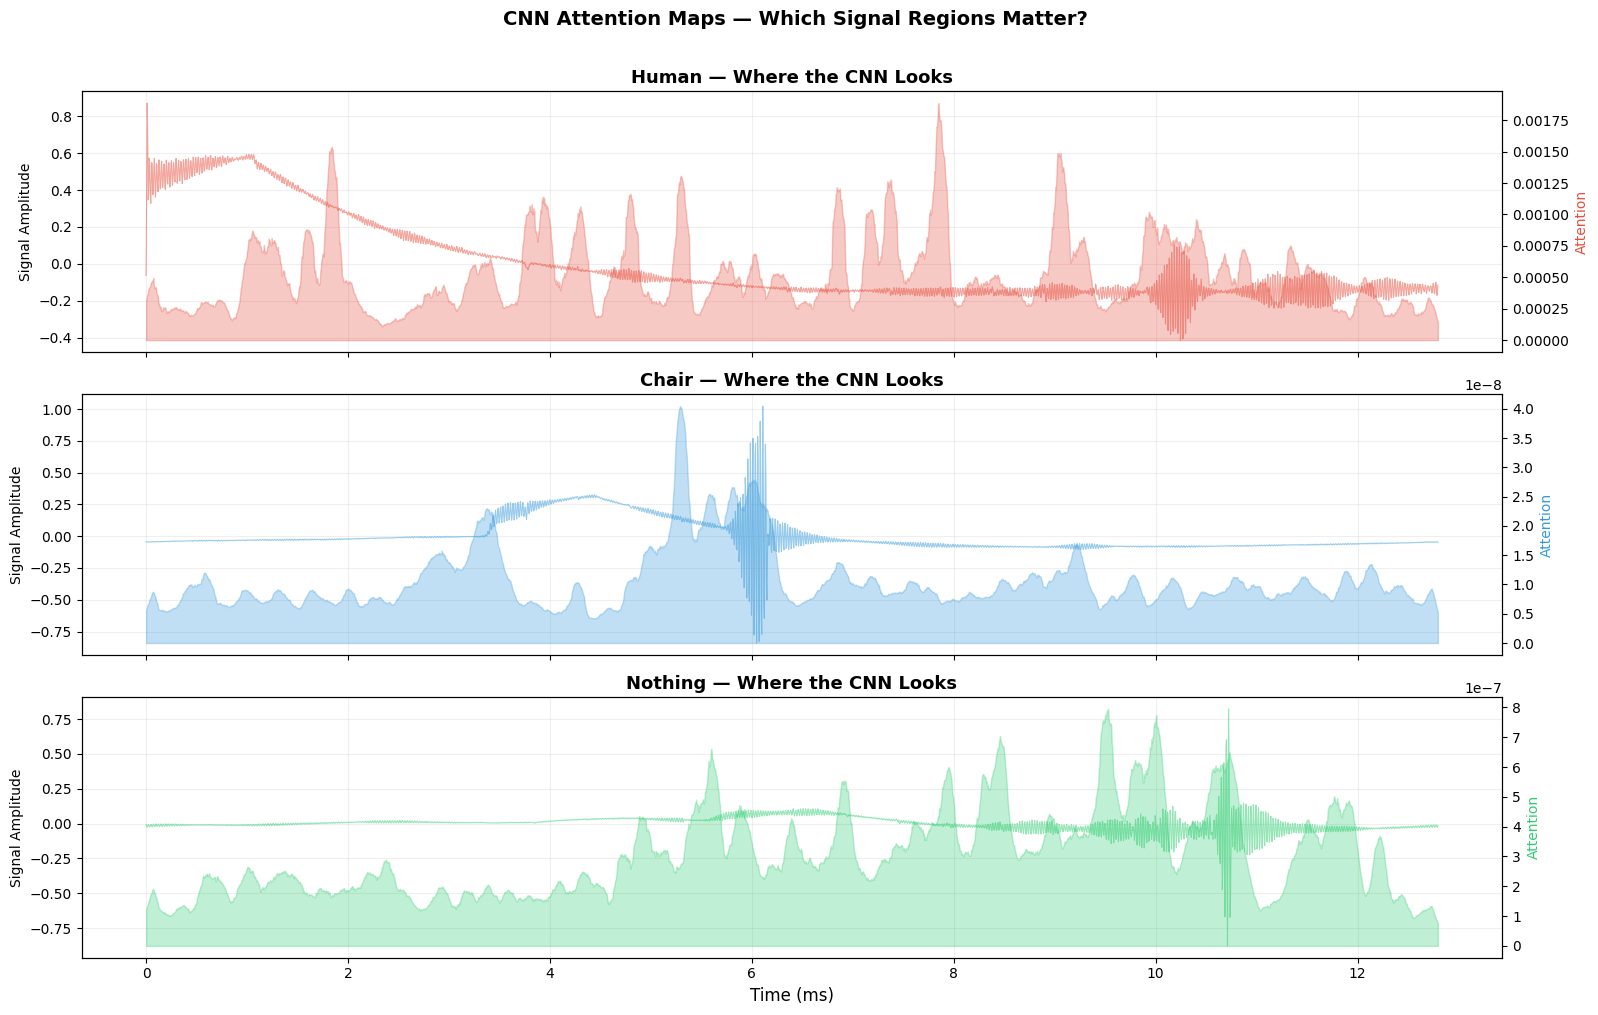

✅ This shows which parts of the echo signal the CNN focuses on for each class.


In [ ]:
# Simple attention-like visualization: compute gradient of output w.r.t. input
# This shows which time regions the CNN considers important

def get_input_gradients(model, x_input, class_idx):
    """Compute gradient of class output w.r.t. input signal."""
    x_tensor = tf.convert_to_tensor(x_input[np.newaxis, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        predictions = model(x_tensor)
        class_output = predictions[0, class_idx]
    gradients = tape.gradient(class_output, x_tensor)
    return np.abs(gradients.numpy()[0, :, 0])

# Compute average attention maps for each class
time_ms = np.arange(DS_LENGTH) * DOWNSAMPLE_FACTOR / SAMPLING_RATE * 1000

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71']

for class_idx, class_name in enumerate(label_names):
    ax = axes[class_idx]

    # Get 20 random test samples of this class
    mask = y_test == class_idx
    class_indices = np.where(mask)[0]
    sample_indices = np.random.RandomState(42).choice(class_indices, size=min(20, len(class_indices)), replace=False)

    # Compute average attention
    attention_sum = np.zeros(DS_LENGTH)
    for idx in sample_indices:
        grad = get_input_gradients(model_cnn, X_test_cnn[idx], class_idx)
        attention_sum += grad
    attention_avg = attention_sum / len(sample_indices)

    # Smooth for visualization
    window = 25
    attention_smooth = np.convolve(attention_avg, np.ones(window)/window, mode='same')

    # Plot signal + attention
    mean_signal = np.mean(X_test_cnn[mask, :, 0], axis=0)
    ax.plot(time_ms, mean_signal, color=colors[class_idx], alpha=0.5, linewidth=0.8, label='Mean signal')

    ax_att = ax.twinx()
    ax_att.fill_between(time_ms, 0, attention_smooth, color=colors[class_idx], alpha=0.3, label='CNN attention')
    ax_att.set_ylabel('Attention', color=colors[class_idx], fontsize=10)

    ax.set_title(f'{class_name} — Where the CNN Looks', fontsize=13, fontweight='bold')
    ax.set_ylabel('Signal Amplitude')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (ms)', fontsize=12)
plt.suptitle('CNN Attention Maps — Which Signal Regions Matter?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/step3_cnn_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ This shows which parts of the echo signal the CNN focuses on for each class.')

## Cell 11 — Save CNN Model

In [ ]:
SAVE_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(SAVE_DIR, exist_ok=True)

# Save as Keras model
cnn_save_path = os.path.join(SAVE_DIR, 'cnn_model.keras')
model_cnn.save(cnn_save_path)
print(f'✅ CNN model saved: {cnn_save_path}')
print(f'   File size: {os.path.getsize(cnn_save_path)/1e6:.1f} MB')

# Also save as TFLite for potential edge deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model_cnn)
tflite_model = converter.convert()

tflite_path = os.path.join(SAVE_DIR, 'cnn_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'✅ TFLite model saved: {tflite_path}')
print(f'   File size: {os.path.getsize(tflite_path)/1e6:.1f} MB (optimized for edge deployment)')

✅ CNN model saved: /content/drive/MyDrive/VER Machine Learning Data/models/cnn_model.keras
   File size: 2.2 MB
Saved artifact at '/tmp/tmp1kvac6pe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2500, 1), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132957505819984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505821904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505822096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505823056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505822672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505817872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505823248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505819408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132957505822864: TensorSpec(shape=(), dtype